# **Predicting Brain Stroke Risk Using Hybrid Machine Learning and Deep Learning Models**

Dataset Links:
- https://www.kaggle.com/datasets/ozguraslank/brain-stroke-ct-dataset

#### **Dataset Downloads**

**Google Colab**

In [1]:
!pip install -q kaggle

In [2]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"efficient8","key":"0e26061c5d5cf73b850e01f7c6575016"}'}

In [3]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [4]:
!kaggle datasets download -d ozguraslank/brain-stroke-ct-dataset

Dataset URL: https://www.kaggle.com/datasets/ozguraslank/brain-stroke-ct-dataset
License(s): other
100% 1.41G/1.41G [00:10<00:00, 138MB/s]



In [5]:
!unzip -q brain-stroke-ct-dataset.zip

**Libraries**

In [6]:
import os
import shutil
import warnings
import random
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

warnings.filterwarnings('ignore')

#### **Dataset Directory**

In [7]:
root_dir = "Brain_Stroke_CT_Dataset"

**Sub Directories**

In [8]:
bleeding_dir_path = os.path.join(root_dir, "Bleeding")
external_test_dir_path = os.path.join(root_dir, "External_Test")
ischemia_dir_path = os.path.join(root_dir, "Ischemia")
normal_dir_path = os.path.join(root_dir, "Normal")

In [9]:
# Sub folders in each sub-directory

sub_dirs = [bleeding_dir_path, external_test_dir_path, normal_dir_path]
sub_folders = {}

for s in sub_dirs:
    sub_folders[s] = os.listdir(s)

sub_folders

{'Brain_Stroke_CT_Dataset/Bleeding': ['OVERLAY', 'DICOM', 'PNG'],
 'Brain_Stroke_CT_Dataset/External_Test': ['OVERLAY',
  'DICOM',
  'MASKS',
  'PNG',
  'labels.csv'],
 'Brain_Stroke_CT_Dataset/Normal': ['DICOM', 'PNG']}

In [10]:
# Count of images in each class
dirs = ['Bleeding', 'External_Test', 'Normal']
count_images = {}
for s in range(len(sub_dirs)):
    count_images[dirs[s]] = len(os.listdir(os.path.join(sub_dirs[s], "PNG")))

count_images

{'Bleeding': 1093, 'External_Test': 200, 'Normal': 4427}

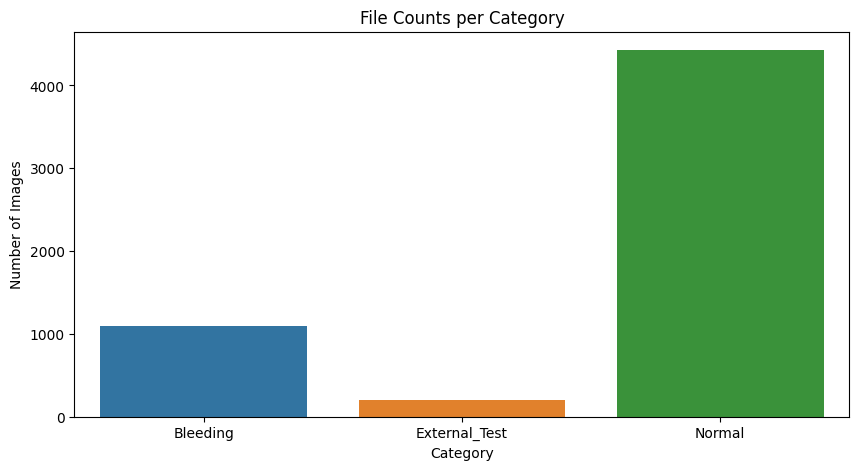

In [11]:
plt.figure(figsize=(10, 5))
sns.barplot(x=count_images.keys(), y=count_images.values(), hue=count_images.keys())
plt.title('File Counts per Category')
plt.ylabel('Number of Images')
plt.xlabel('Category')
plt.show()

**Sample Data Visualization**

['External_Test', 'Ischemia', 'Normal', 'Bleeding']
Folder is Brain_Stroke_CT_Dataset/External_Test/PNG
Folder is Brain_Stroke_CT_Dataset/Ischemia/PNG
Folder is Brain_Stroke_CT_Dataset/Normal/PNG
Folder is Brain_Stroke_CT_Dataset/Bleeding/PNG


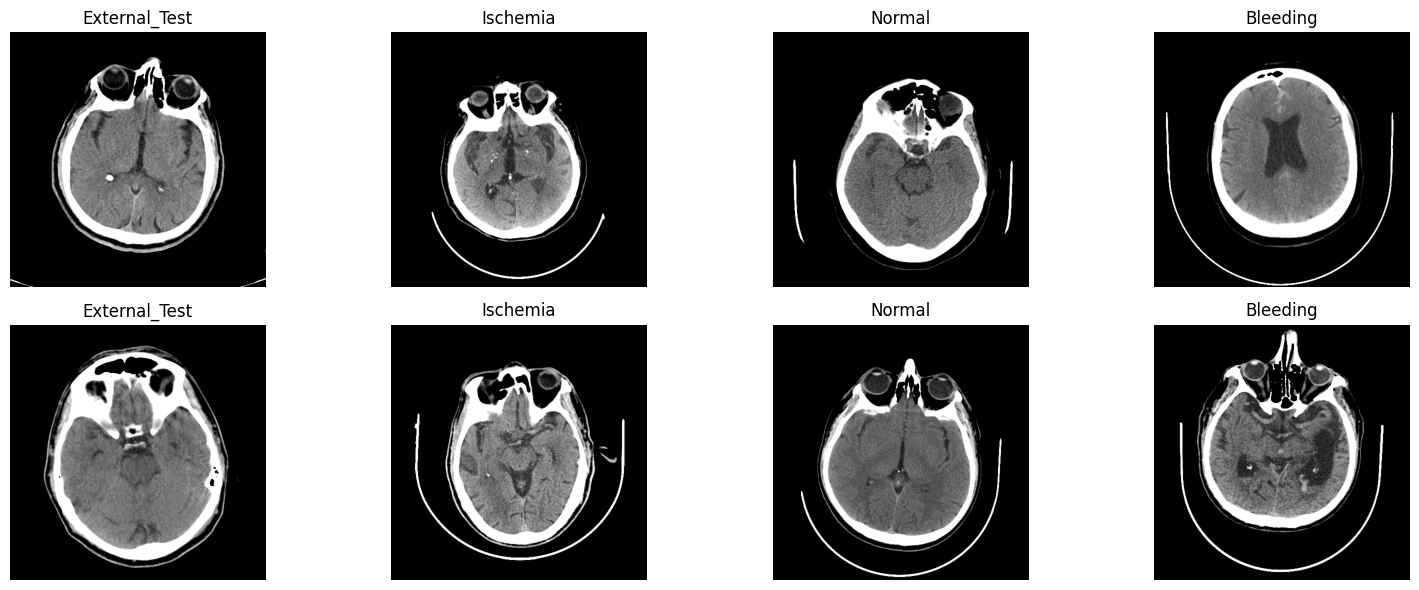

In [12]:
import matplotlib.image as mpimg

categories = os.listdir(root_dir)
print(categories)

num_categories = len(categories)
fig, axes = plt.subplots(2, num_categories, figsize=(4*num_categories, 6))

# If only 1 category, make axes 2D
if num_categories == 1:
    axes = axes.reshape(2, 1)

for i, category in enumerate(categories):
    folder = os.path.join(root_dir, category, "PNG")
    print(f"Folder is {folder}")

    images = [f for f in os.listdir(folder) if os.path.isfile(os.path.join(folder, f))]
    sample_imgs = random.sample(images, 2) if len(images) >= 2 else images

    for j, img_name in enumerate(sample_imgs):
        ax = axes[j, i]
        img_path = os.path.join(folder, img_name)
        img = mpimg.imread(img_path)

        ax.imshow(img, cmap='gray')
        ax.set_title(category)
        ax.axis('off')

    # If less than 2 images, hide remaining subplot
    for j in range(len(sample_imgs), 2):
        axes[j, i].axis('off')

plt.tight_layout()
plt.show()

In [13]:
count_images = {
    'Bleeding': count_images['Bleeding'],
    'External_Test': count_images['External_Test'],
    'Normal': 1100 # Reduce Normal to 1100 images
}

dirs = list(count_images.keys())

classes = list(count_images.keys())

print(f"Updated image counts: {count_images}")
print(f"Updated list of directories/classes: {classes}")

Updated image counts: {'Bleeding': 1093, 'External_Test': 200, 'Normal': 1100}
Updated list of directories/classes: ['Bleeding', 'External_Test', 'Normal']


In [14]:
# Source and Target Paths
source_root = "Brain_Stroke_CT_Dataset"
target_root = "data"

classes = os.listdir(root_dir)

for cls in classes:
    source_folder = os.path.join(source_root, cls, "PNG")
    target_folder = os.path.join(target_root, cls)

    # Create target folder if not exists
    os.makedirs(target_folder, exist_ok=True)

    print(f"\nCopying from {source_folder} to {target_folder}")

    for file in os.listdir(source_folder):
        src_file = os.path.join(source_folder, file)
        dst_file = os.path.join(target_folder, file)

        if os.path.isfile(src_file):
            shutil.copy2(src_file, dst_file)

    print(f"{cls} copied successfully")

print("\nAll folders copied successfully")


Copying from Brain_Stroke_CT_Dataset/External_Test/PNG to data/External_Test
External_Test copied successfully

Copying from Brain_Stroke_CT_Dataset/Ischemia/PNG to data/Ischemia
Ischemia copied successfully

Copying from Brain_Stroke_CT_Dataset/Normal/PNG to data/Normal
Normal copied successfully

Copying from Brain_Stroke_CT_Dataset/Bleeding/PNG to data/Bleeding
Bleeding copied successfully

All folders copied successfully


**Train, Test and Validation**

In [15]:
# Paths
source_dir = "data"
target_dir = "stroke_split"

# Split ratios
train_ratio = 0.8
val_ratio = 0.1
test_ratio = 0.1

classes = os.listdir(source_dir)

# Create folder structure
for split in ["train", "val", "test"]:
    for cls in classes:
        os.makedirs(os.path.join(target_dir, split, cls), exist_ok=True)

for cls in classes:
    class_path = os.path.join(source_dir, cls)
    images = [f for f in os.listdir(class_path)
              if os.path.isfile(os.path.join(class_path, f))]

    # IMPORTANT PART
    if cls == "Normal":
        if len(images) > 1200:
            images = random.sample(images, 1200)
            print(f"\nUsing 1200 random images from Normal")
        else:
            print(f"\nNormal has less than 1200 images, using all images")

    random.shuffle(images)

    total = len(images)
    train_end = int(total * train_ratio)
    val_end = train_end + int(total * val_ratio)

    train_imgs = images[:train_end]
    val_imgs = images[train_end:val_end]
    test_imgs = images[val_end:]

    print(f"\nClass: {cls}")
    print(f"Total Used: {total}")
    print(f"Train: {len(train_imgs)} | Val: {len(val_imgs)} | Test: {len(test_imgs)}")

    for img in train_imgs:
        shutil.copy2(
            os.path.join(class_path, img),
            os.path.join(target_dir, "train", cls, img)
        )

    for img in val_imgs:
        shutil.copy2(
            os.path.join(class_path, img),
            os.path.join(target_dir, "val", cls, img)
        )

    for img in test_imgs:
        shutil.copy2(
            os.path.join(class_path, img),
            os.path.join(target_dir, "test", cls, img)
        )

print("\nDataset split completed successfully")


Class: External_Test
Total Used: 200
Train: 160 | Val: 20 | Test: 20

Class: Ischemia
Total Used: 1130
Train: 904 | Val: 113 | Test: 113

Using 1200 random images from Normal

Class: Normal
Total Used: 1200
Train: 960 | Val: 120 | Test: 120

Class: Bleeding
Total Used: 1093
Train: 874 | Val: 109 | Test: 110

Dataset split completed successfully


**Data after train, test and validation split**

In [16]:
train_parent_dir = r"stroke_split/train"
print("Count of Images for each class in train directory")
for f in classes:
    count_of_images = len(os.listdir(os.path.join(train_parent_dir, f)))
    print(f"{f} has {count_of_images} images")

Count of Images for each class in train directory
External_Test has 160 images
Ischemia has 904 images
Normal has 960 images
Bleeding has 874 images


In [17]:
val_parent_dir = "stroke_split/val"
print("Count of Images for each class in val directory")
for f in classes:
    count_of_images = len(os.listdir(os.path.join(val_parent_dir, f)))
    print(f"{f} has {count_of_images} images")

Count of Images for each class in val directory
External_Test has 20 images
Ischemia has 113 images
Normal has 120 images
Bleeding has 109 images


In [18]:
test_parent_dir = "stroke_split/test"
print("Count of Images for each class in test directory")
for f in classes:
    count_of_images = len(os.listdir(os.path.join(test_parent_dir, f)))
    print(f"{f} has {count_of_images} images")

Count of Images for each class in test directory
External_Test has 20 images
Ischemia has 113 images
Normal has 120 images
Bleeding has 110 images


#### **Data Augmentation**

In [74]:
train_dir = "stroke_split/train"
val_dir = "stroke_split/val"
test_dir = "stroke_split/test"

In [75]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [76]:
img_dims = (256, 256)
batch_size = 32

In [77]:
train_data = ImageDataGenerator(
    rescale=1./255,
    rotation_range=45,
    zoom_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)

train_generator = train_data.flow_from_directory(
    directory=train_dir,
    target_size= img_dims,
    batch_size=batch_size,
    class_mode='categorical'
)

Found 2898 images belonging to 4 classes.


In [78]:
val_test_datagen = ImageDataGenerator(rescale=1./255)

val_generator = val_test_datagen.flow_from_directory(
    directory=val_dir,
    target_size=img_dims,
    batch_size=batch_size,
    class_mode='categorical'
)

Found 362 images belonging to 4 classes.


In [79]:
test_generator = val_test_datagen.flow_from_directory(
    test_dir,
    target_size=img_dims,
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)

Found 363 images belonging to 4 classes.


In [80]:
train_generator.class_indices

{'Bleeding': 0, 'External_Test': 1, 'Ischemia': 2, 'Normal': 3}

## **Models**

In [81]:
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize
from sklearn.metrics import classification_report
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization, Input
from collections import Counter
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam


In [82]:
from collections import Counter

# Get class labels
class_labels = train_generator.class_indices
print("Class Labels:", class_labels)

# Count samples
counts = Counter(train_generator.classes)

# Imbalance Ratio
counts_list = np.array(list(counts.values()))

imbalance_ratio = counts_list.max() / counts_list.min()
print(f"\nImbalance Ratio: {imbalance_ratio:.2f}")

Class Labels: {'Bleeding': 0, 'External_Test': 1, 'Ischemia': 2, 'Normal': 3}

Imbalance Ratio: 6.00


In [83]:
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_generator.classes),
    y=train_generator.classes
)

class_weights = dict(enumerate(class_weights))
print("\nClass Weights:", class_weights)


Class Weights: {0: np.float64(0.8289473684210527), 1: np.float64(4.528125), 2: np.float64(0.8014380530973452), 3: np.float64(0.7546875)}


**Evaluation Metrics**

In [84]:
def get_metrics(model, generator, model_name):

    generator.reset()

    y_true = generator.classes
    y_pred = np.argmax(model.predict(generator), axis=1)

    report = classification_report(y_true, y_pred, output_dict=True)

    return {
        "Model": model_name,
        "Accuracy": report["accuracy"],
        "Precision": report["weighted avg"]["precision"],
        "Recall": report["weighted avg"]["recall"],
        "F1 Score": report["weighted avg"]["f1-score"]
    }

**Confusion Matrix Function**

In [85]:
def cm_model(model, generator, model_name, color):

    y_true = generator.classes
    y_pred_prob = model.predict(generator)
    y_pred = np.argmax(y_pred_prob, axis=1)

    # Get class labels
    class_labels = list(generator.class_indices.keys())
    class_labels = [k for k, v in sorted(generator.class_indices.items(), key=lambda item: item[1])]

    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(6,5))
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap=color,
        xticklabels=class_labels,
        yticklabels=class_labels
    )
    plt.title(f"{model_name} - Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

**ROC-AUC Curve**

In [86]:
def roc_model(model, generator, model_name, color):

    y_true = generator.classes
    y_pred_prob = model.predict(generator)
    y_pred = np.argmax(y_pred_prob, axis=1)

    # ROC Curve (One vs Rest)
    y_true_bin = label_binarize(y_true, classes=[0,1,2])

    plt.figure(figsize=(6,5))

    for i in range(3):
        fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_pred_prob[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, color=color, label=f'Class {i} AUC = {roc_auc:.2f}')

    plt.plot([0,1], [0,1], 'k--')
    plt.title(f"{model_name} - ROC Curve")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend()
    plt.show()

In [87]:
results = []

## **Normal Models**

#### **Custom CNN Model**

In [88]:
callbacks = [
    EarlyStopping(patience=5, restore_best_weights=True),
    ReduceLROnPlateau(factor=0.3, patience=3)
]

In [89]:
class_len = train_generator.num_classes
classes = os.listdir(root_dir)
epochs = 30

In [90]:
cnn_model = Sequential([
    Input(shape=(img_dims[0],img_dims[1],3)),

    # First block
    Conv2D(32, kernel_size=3, activation='relu', padding='same'),
    BatchNormalization(),
    Conv2D(32, kernel_size=3, activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2, 2)),
    Dropout(0.25),

    # Second block
    Conv2D(64, kernel_size=3, activation='relu', padding='same'),
    BatchNormalization(),
    Conv2D(64, kernel_size=3, activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2, 2)),
    Dropout(0.25),

    # Third block
    Conv2D(128, kernel_size=3, activation='relu', padding='same'),
    BatchNormalization(),
    Conv2D(128, kernel_size=3, activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2, 2)),
    Dropout(0.25),

    # Fourth block
    Conv2D(256, kernel_size=3, activation='relu', padding='same'),
    BatchNormalization(),
    Conv2D(256, kernel_size=3, activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2, 2)),
    Dropout(0.5),

    # Classifier
    Flatten(),
    Dense(512, activation='relu'),
    BatchNormalization(),
    Dropout(0.5),
    Dense(256, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),
    Dense(class_len, activation='softmax')
])

In [91]:
from tensorflow.keras.metrics import F1Score

# Compile with different optimizer settings
cnn_model.compile(
    optimizer=Adam(learning_rate=0.0001, decay=1e-6),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [92]:
# Train Model
history_cnn = cnn_model.fit(train_generator, epochs=epochs, verbose=1,
          validation_data=val_generator, class_weight=class_weights, callbacks=callbacks)

Epoch 1/30
91/91 ━━━━━━━━━━━━━━━━━━━━ 133s 1s/step - accuracy: 0.2716 - loss: 2.1165 - val_accuracy: 0.0552 - val_loss: 2.9602 - learning_rate: 1.0000e-04
Epoch 2/30
91/91 ━━━━━━━━━━━━━━━━━━━━ 58s 640ms/step - accuracy: 0.2930 - loss: 2.0186 - val_accuracy: 0.0580 - val_loss: 2.7834 - learning_rate: 1.0000e-04
Epoch 3/30
91/91 ━━━━━━━━━━━━━━━━━━━━ 57s 624ms/step - accuracy: 0.3050 - loss: 1.8680 - val_accuracy: 0.3122 - val_loss: 2.6316 - learning_rate: 1.0000e-04
Epoch 4/30
91/91 ━━━━━━━━━━━━━━━━━━━━ 57s 631ms/step - accuracy: 0.3209 - loss: 1.7526 - val_accuracy: 0.3122 - val_loss: 2.8183 - learning_rate: 1.0000e-04
Epoch 5/30
91/91 ━━━━━━━━━━━━━━━━━━━━ 57s 624ms/step - accuracy: 0.3126 - loss: 1.7660 - val_accuracy: 0.3122 - val_loss: 2.5629 - learning_rate: 1.0000e-04
Epoch 6/30
91/91 ━━━━━━━━━━━━━━━━━━━━ 57s 629ms/step - accuracy: 0.3323 - loss: 1.7402 - val_accuracy: 0.3122 - val_loss: 2.2126 - learning_rate: 1.0000e-04
Epoch 7/30
91/91 ━━━━━━━━━━━━━━━━━━━━ 57s 621ms/step - accur

In [93]:
results.append(get_metrics(cnn_model, test_generator, "CNN"))

12/12 ━━━━━━━━━━━━━━━━━━━━ 6s 421ms/step


12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 126ms/step


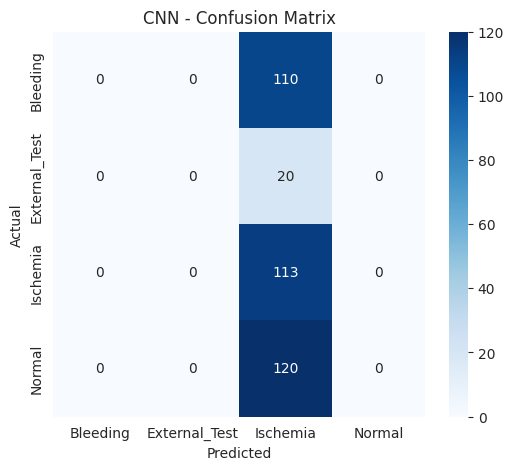

In [95]:
cm_model(cnn_model, test_generator, "CNN", "Blues")

12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 129ms/step


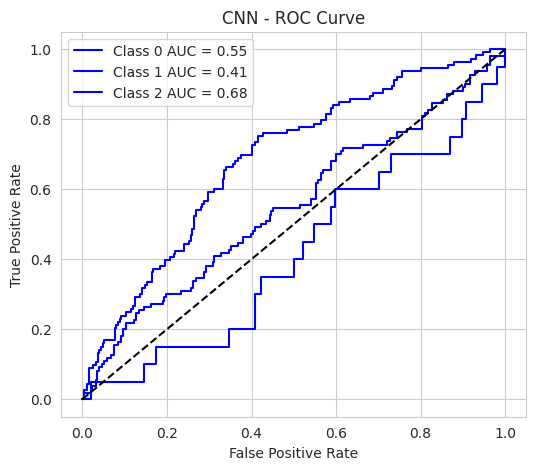

In [96]:
roc_model(cnn_model, test_generator, "CNN", "blue")

#### **MobileNetV2**

In [97]:
base_model_mob = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(img_dims[0],img_dims[1],3)
)

# Freeze layers
for layer in base_model_mob.layers:
    layer.trainable = False

mob_model = Sequential([
    base_model_mob,
    GlobalAveragePooling2D(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(class_len, activation='softmax')
])

In [98]:
mob_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [99]:
history_mob = mob_model.fit(
    train_generator,
    validation_data=val_generator,
    class_weight=class_weights,
    epochs=epochs,
    callbacks=callbacks
)

Epoch 1/30
91/91 ━━━━━━━━━━━━━━━━━━━━ 111s 912ms/step - accuracy: 0.3727 - loss: 1.4169 - val_accuracy: 0.5138 - val_loss: 1.1997 - learning_rate: 0.0010
Epoch 2/30
91/91 ━━━━━━━━━━━━━━━━━━━━ 52s 576ms/step - accuracy: 0.4600 - loss: 1.2555 - val_accuracy: 0.5773 - val_loss: 1.1361 - learning_rate: 0.0010
Epoch 3/30
91/91 ━━━━━━━━━━━━━━━━━━━━ 51s 557ms/step - accuracy: 0.5166 - loss: 1.2148 - val_accuracy: 0.4613 - val_loss: 1.2291 - learning_rate: 0.0010
Epoch 4/30
91/91 ━━━━━━━━━━━━━━━━━━━━ 52s 569ms/step - accuracy: 0.4907 - loss: 1.1984 - val_accuracy: 0.5359 - val_loss: 1.1638 - learning_rate: 0.0010
Epoch 5/30
91/91 ━━━━━━━━━━━━━━━━━━━━ 52s 577ms/step - accuracy: 0.5186 - loss: 1.1797 - val_accuracy: 0.5829 - val_loss: 1.1150 - learning_rate: 0.0010
Epoch 6/30
91/91 ━━━━━━━━━━━━━━━━━━━━ 50s 554ms/step - accuracy: 0.5359 - loss: 1.1661 - val_accuracy: 0.5635 - val_loss: 1.1424 - learning_rate: 0.0010
Epoch 7/30
91/91 ━━━━━━━━━━━━━━━━━━━━ 51s 559ms/step - accuracy: 0.5807 - loss: 1

In [100]:
results.append(get_metrics(mob_model, test_generator, "MobileNet"))

12/12 ━━━━━━━━━━━━━━━━━━━━ 21s 1s/step


12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 127ms/step


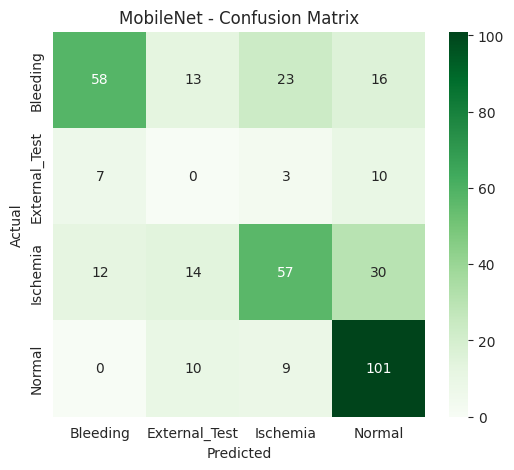

In [102]:
cm_model(mob_model, test_generator, "MobileNet", "Greens")

12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 118ms/step


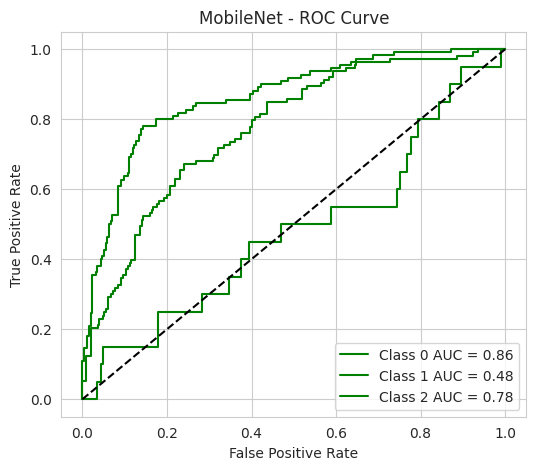

In [103]:
roc_model(mob_model, test_generator, "MobileNet", "green")

#### **ResNet**

In [104]:
base_model_res = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(img_dims[0],img_dims[1],3)
)

# Freeze layers
for layer in base_model_res.layers:
    layer.trainable = False

res_model = Sequential([
    base_model_res,
    GlobalAveragePooling2D(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(class_len, activation='softmax')
])

In [105]:
res_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [106]:
history_res = res_model.fit(
    train_generator,
    validation_data=val_generator,
    class_weight=class_weights,
    epochs=epochs,
    callbacks=callbacks
)

Epoch 1/30
91/91 ━━━━━━━━━━━━━━━━━━━━ 82s 725ms/step - accuracy: 0.2878 - loss: 1.5156 - val_accuracy: 0.4199 - val_loss: 1.3467 - learning_rate: 0.0010
Epoch 2/30
91/91 ━━━━━━━━━━━━━━━━━━━━ 53s 579ms/step - accuracy: 0.3226 - loss: 1.3761 - val_accuracy: 0.3536 - val_loss: 1.3560 - learning_rate: 0.0010
Epoch 3/30
91/91 ━━━━━━━━━━━━━━━━━━━━ 53s 577ms/step - accuracy: 0.3364 - loss: 1.3657 - val_accuracy: 0.4530 - val_loss: 1.3202 - learning_rate: 0.0010
Epoch 4/30
91/91 ━━━━━━━━━━━━━━━━━━━━ 52s 573ms/step - accuracy: 0.4075 - loss: 1.3426 - val_accuracy: 0.4171 - val_loss: 1.3214 - learning_rate: 3.0000e-04
Epoch 5/30
91/91 ━━━━━━━━━━━━━━━━━━━━ 53s 577ms/step - accuracy: 0.3699 - loss: 1.3477 - val_accuracy: 0.4669 - val_loss: 1.2986 - learning_rate: 3.0000e-04


In [107]:
results.append(get_metrics(res_model, test_generator, "ResNet"))

12/12 ━━━━━━━━━━━━━━━━━━━━ 11s 582ms/step


12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 155ms/step


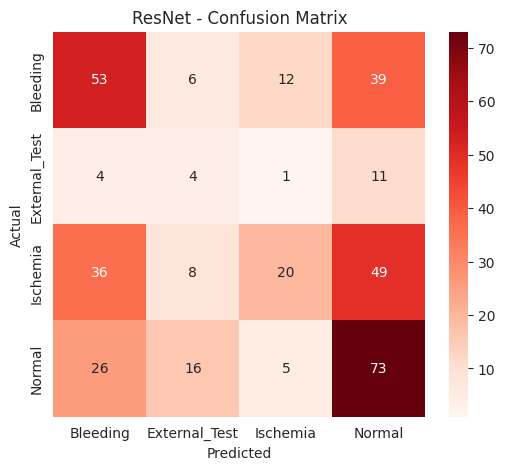

In [108]:
cm_model(res_model, test_generator, "ResNet", "Reds")

12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 136ms/step


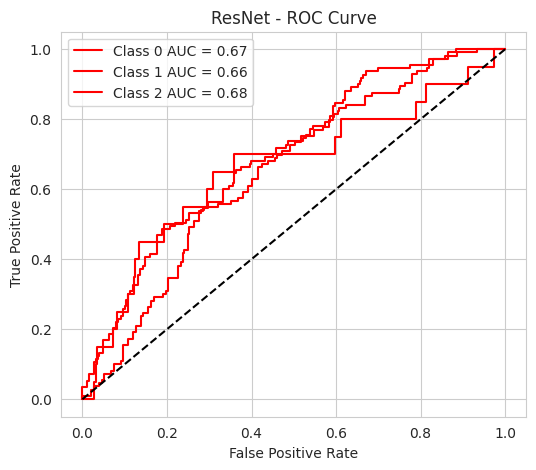

In [109]:
roc_model(res_model, test_generator, "ResNet", "red")

## **Fine Tuned Models**

#### **MobileNetV2 Fine Tuned**

In [110]:
# Unfreeze last 30 layers
for layer in base_model_mob.layers[-30:]:
    layer.trainable = True

mob_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [111]:
history_mob_ft = mob_model.fit(
    train_generator,
    validation_data=val_generator,
    class_weight=class_weights,
    epochs=epochs,
    callbacks=callbacks
)

Epoch 1/30
91/91 ━━━━━━━━━━━━━━━━━━━━ 95s 781ms/step - accuracy: 0.5594 - loss: 1.5334 - val_accuracy: 0.6381 - val_loss: 1.0075 - learning_rate: 1.0000e-05
Epoch 2/30
91/91 ━━━━━━━━━━━━━━━━━━━━ 53s 577ms/step - accuracy: 0.5794 - loss: 1.3253 - val_accuracy: 0.6298 - val_loss: 0.9966 - learning_rate: 1.0000e-05
Epoch 3/30
91/91 ━━━━━━━━━━━━━━━━━━━━ 52s 568ms/step - accuracy: 0.5794 - loss: 1.2130 - val_accuracy: 0.6326 - val_loss: 0.9918 - learning_rate: 1.0000e-05
Epoch 4/30
91/91 ━━━━━━━━━━━━━━━━━━━━ 51s 563ms/step - accuracy: 0.5745 - loss: 1.1484 - val_accuracy: 0.6354 - val_loss: 0.9748 - learning_rate: 1.0000e-05
Epoch 5/30
91/91 ━━━━━━━━━━━━━━━━━━━━ 51s 556ms/step - accuracy: 0.5863 - loss: 1.1028 - val_accuracy: 0.6381 - val_loss: 0.9659 - learning_rate: 1.0000e-05
Epoch 6/30
91/91 ━━━━━━━━━━━━━━━━━━━━ 50s 550ms/step - accuracy: 0.6063 - loss: 1.0720 - val_accuracy: 0.6464 - val_loss: 0.9688 - learning_rate: 1.0000e-05
Epoch 7/30
91/91 ━━━━━━━━━━━━━━━━━━━━ 51s 558ms/step - acc

In [112]:
results.append(get_metrics(mob_model, test_generator, "MobileNet FT"))

12/12 ━━━━━━━━━━━━━━━━━━━━ 14s 724ms/step


12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 124ms/step


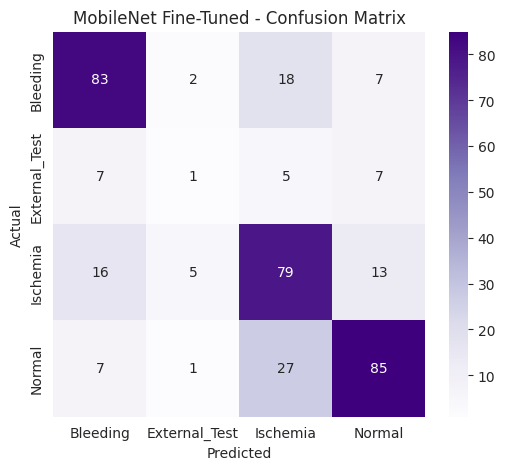

In [113]:
cm_model(mob_model, test_generator, "MobileNet Fine-Tuned", "Purples")

12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 121ms/step


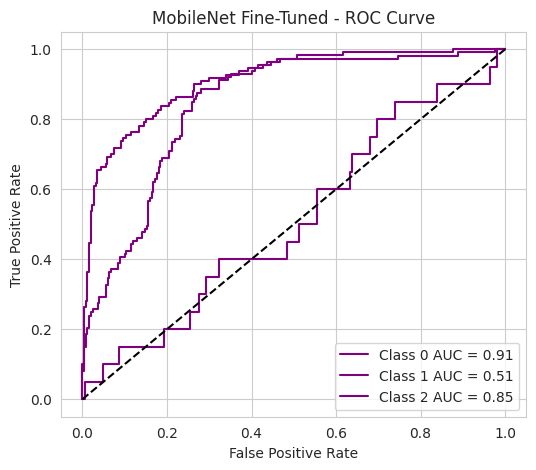

In [114]:
roc_model(mob_model, test_generator, "MobileNet Fine-Tuned", "purple")

#### **ResNet Fine Tuned Models**

In [115]:
# Unfreeze last 40 layers
for layer in base_model_res.layers[-40:]:
    layer.trainable = True

res_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [116]:
history_res_ft = res_model.fit(
    train_generator,
    validation_data=val_generator,
    class_weight=class_weights,
    epochs=epochs,
    callbacks=callbacks
)

Epoch 1/30
91/91 ━━━━━━━━━━━━━━━━━━━━ 92s 767ms/step - accuracy: 0.3268 - loss: 1.5825 - val_accuracy: 0.3646 - val_loss: 1.3165 - learning_rate: 1.0000e-05
Epoch 2/30
91/91 ━━━━━━━━━━━━━━━━━━━━ 56s 612ms/step - accuracy: 0.3195 - loss: 1.4090 - val_accuracy: 0.4144 - val_loss: 1.2978 - learning_rate: 1.0000e-05
Epoch 3/30
91/91 ━━━━━━━━━━━━━━━━━━━━ 55s 609ms/step - accuracy: 0.3464 - loss: 1.3545 - val_accuracy: 0.4420 - val_loss: 1.2720 - learning_rate: 1.0000e-05
Epoch 4/30
91/91 ━━━━━━━━━━━━━━━━━━━━ 56s 613ms/step - accuracy: 0.3589 - loss: 1.3519 - val_accuracy: 0.4088 - val_loss: 1.2627 - learning_rate: 3.0000e-06
Epoch 5/30
91/91 ━━━━━━━━━━━━━━━━━━━━ 56s 615ms/step - accuracy: 0.3640 - loss: 1.3349 - val_accuracy: 0.4365 - val_loss: 1.2468 - learning_rate: 3.0000e-06


In [117]:
results.append(get_metrics(res_model, test_generator, "ResNet FT"))

12/12 ━━━━━━━━━━━━━━━━━━━━ 10s 517ms/step


12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 130ms/step


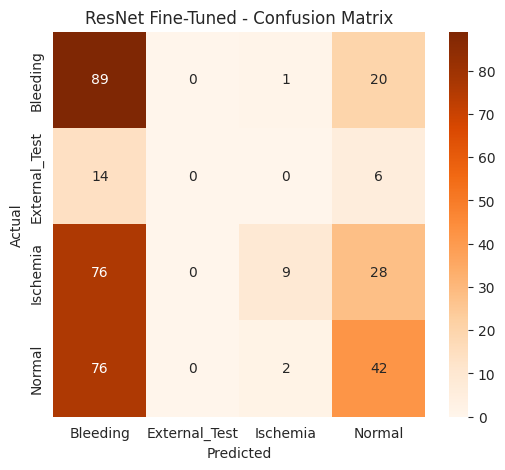

In [118]:
cm_model(res_model, test_generator, "ResNet Fine-Tuned", "Oranges")

12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 173ms/step


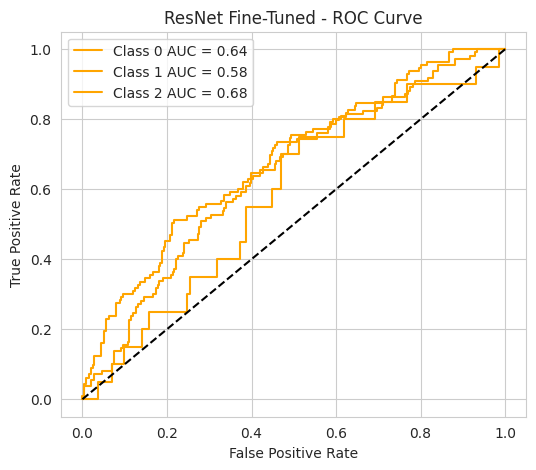

In [119]:
roc_model(res_model, test_generator, "ResNet Fine-Tuned", "orange")

## **Accuracy Plot for Normal Models**

**Accuracy Curve**

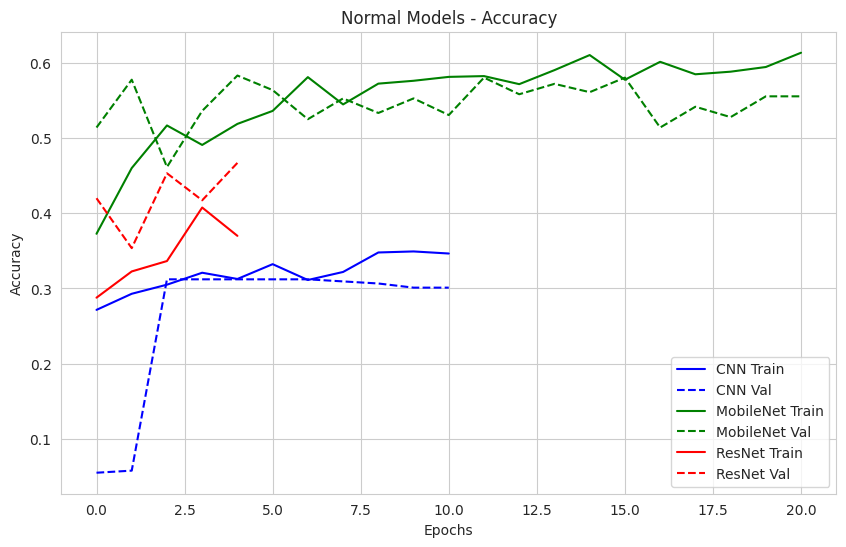

In [120]:
sns.set_style("whitegrid")

# Accuracy Plot
plt.figure(figsize=(10,6))

plt.plot(history_cnn.history['accuracy'], label='CNN Train', color='blue')
plt.plot(history_cnn.history['val_accuracy'], label='CNN Val', linestyle='--', color='blue')

plt.plot(history_mob.history['accuracy'], label='MobileNet Train', color='green')
plt.plot(history_mob.history['val_accuracy'], label='MobileNet Val', linestyle='--', color='green')

plt.plot(history_res.history['accuracy'], label='ResNet Train', color='red')
plt.plot(history_res.history['val_accuracy'], label='ResNet Val', linestyle='--', color='red')

plt.title('Normal Models - Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

**Loss Curve**

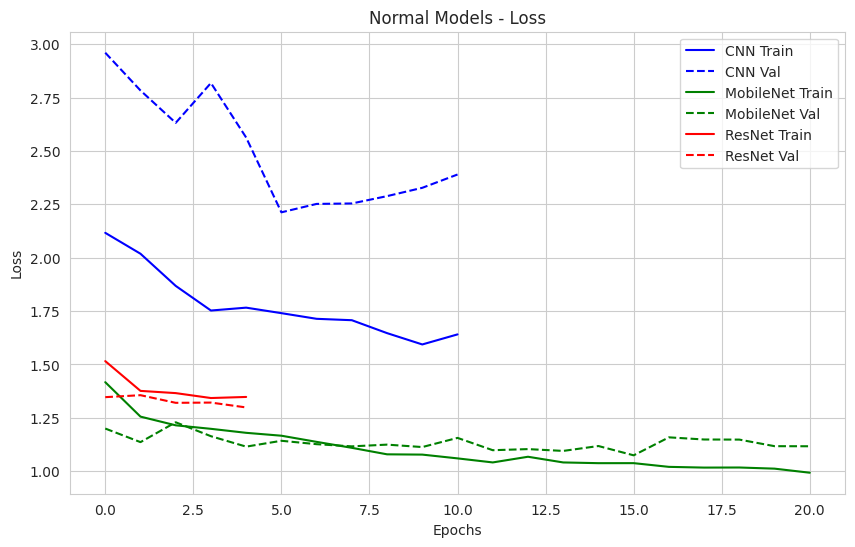

In [121]:
# Loss Plot
plt.figure(figsize=(10,6))

plt.plot(history_cnn.history['loss'], label='CNN Train', color='blue')
plt.plot(history_cnn.history['val_loss'], label='CNN Val', linestyle='--', color='blue')

plt.plot(history_mob.history['loss'], label='MobileNet Train', color='green')
plt.plot(history_mob.history['val_loss'], label='MobileNet Val', linestyle='--', color='green')

plt.plot(history_res.history['loss'], label='ResNet Train', color='red')
plt.plot(history_res.history['val_loss'], label='ResNet Val', linestyle='--', color='red')

plt.title('Normal Models - Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

#### **Fine Tuned Models Curves**

**Accuracy Curve**

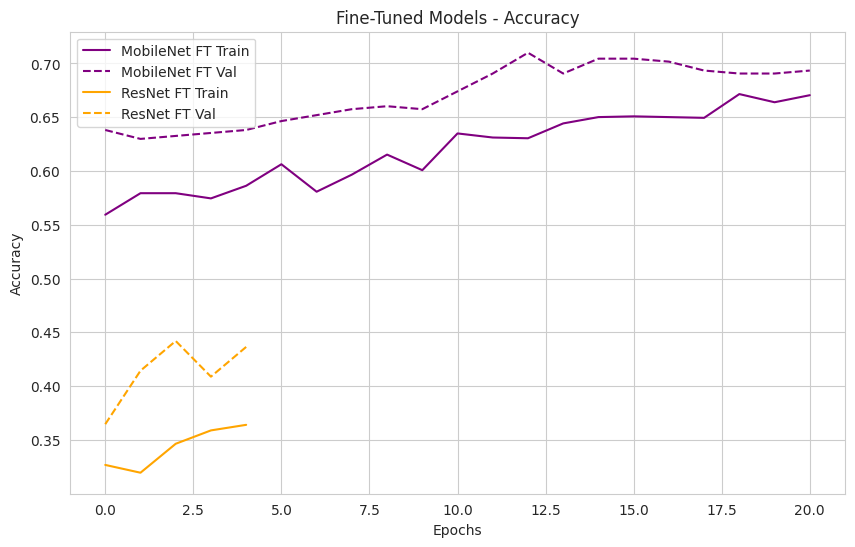

In [122]:
# Accuracy Plot
plt.figure(figsize=(10,6))

plt.plot(history_mob_ft.history['accuracy'], label='MobileNet FT Train', color='purple')
plt.plot(history_mob_ft.history['val_accuracy'], label='MobileNet FT Val', linestyle='--', color='purple')

plt.plot(history_res_ft.history['accuracy'], label='ResNet FT Train', color='orange')
plt.plot(history_res_ft.history['val_accuracy'], label='ResNet FT Val', linestyle='--', color='orange')

plt.title('Fine-Tuned Models - Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

**Loss Curves**

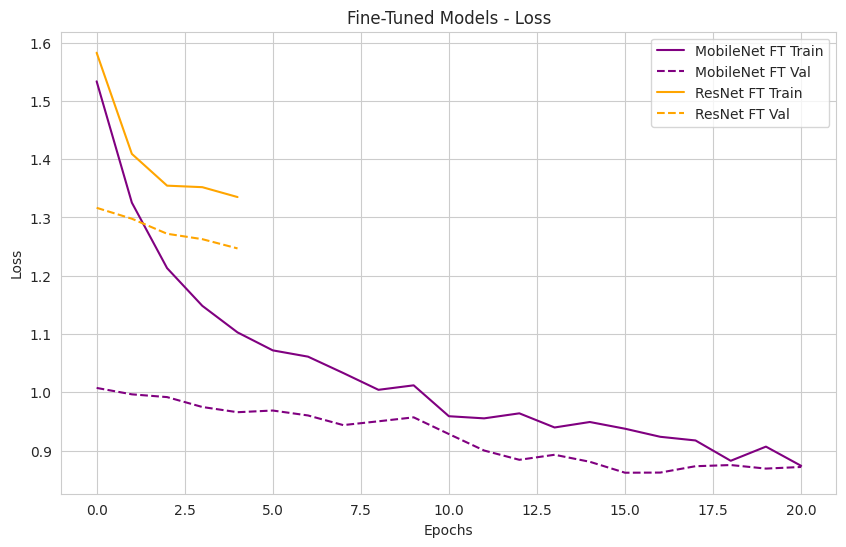

In [123]:
# Loss Plot
plt.figure(figsize=(10,6))

plt.plot(history_mob_ft.history['loss'], label='MobileNet FT Train', color='purple')
plt.plot(history_mob_ft.history['val_loss'], label='MobileNet FT Val', linestyle='--', color='purple')

plt.plot(history_res_ft.history['loss'], label='ResNet FT Train', color='orange')
plt.plot(history_res_ft.history['val_loss'], label='ResNet FT Val', linestyle='--', color='orange')

plt.title('Fine-Tuned Models - Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

## **Metrics**

In [124]:
df = pd.DataFrame(results)
print(df)

          Model  Accuracy  Precision    Recall  F1 Score
0           CNN  0.311295   0.096904  0.311295  0.147800
1     MobileNet  0.595041   0.633789  0.595041  0.602158
2        ResNet  0.413223   0.445588  0.413223  0.396181
3  MobileNet FT  0.683196   0.670225  0.683196  0.674850
4     ResNet FT  0.385675   0.483863  0.385675  0.321164


In [125]:
normal_df = df.iloc[:3]
ft_df = df.iloc[3:]

**Metrics for Normal Models**

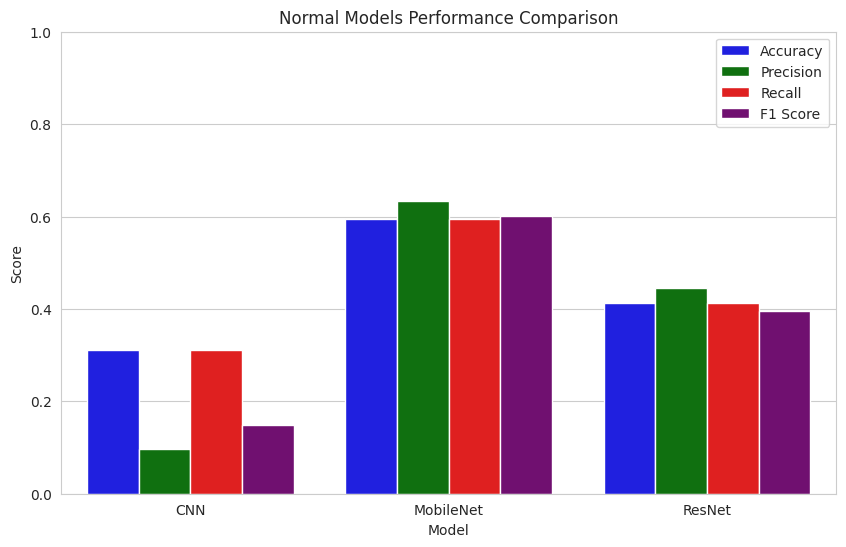

In [126]:
sns.set_style("whitegrid")

normal_melted = normal_df.melt(id_vars="Model",
                               var_name="Metric",
                               value_name="Score")

plt.figure(figsize=(10,6))
sns.barplot(data=normal_melted, x="Model", y="Score", hue="Metric",
            palette=["blue", "green", "red", "purple"])

plt.title("Normal Models Performance Comparison")
plt.ylim(0,1)
plt.legend(loc='upper right')
plt.show()

**Metrics for Fine Tuned Models**

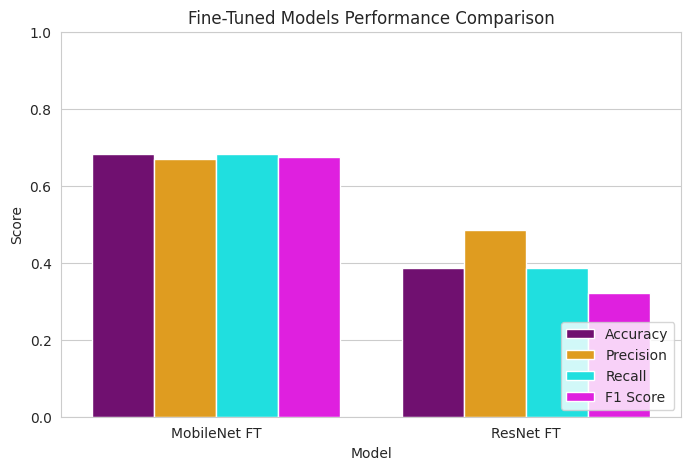

In [127]:
ft_melted = ft_df.melt(id_vars="Model",
                       var_name="Metric",
                       value_name="Score")

plt.figure(figsize=(8,5))
sns.barplot(data=ft_melted, x="Model", y="Score", hue="Metric",
            palette=["purple", "orange", "cyan", "magenta"])

plt.title("Fine-Tuned Models Performance Comparison")
plt.ylim(0,1)
plt.legend(loc='lower right')
plt.show()

## **ROC Curve**

12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 119ms/step
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 118ms/step
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 130ms/step
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 115ms/step
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 139ms/step


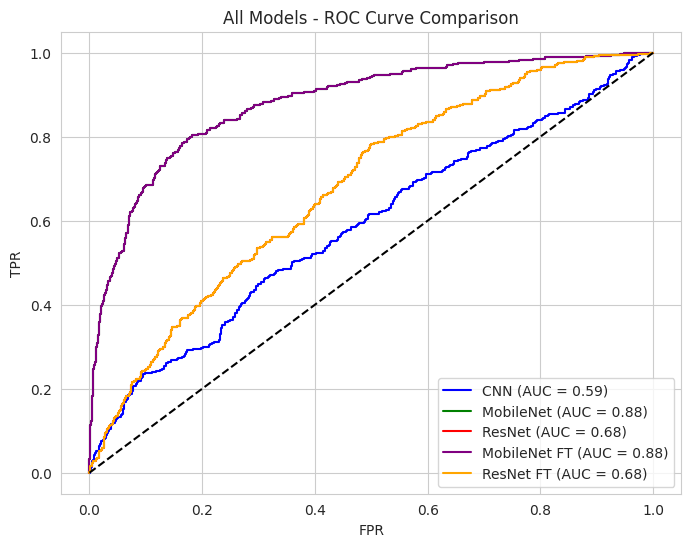

In [128]:
plt.figure(figsize=(8,6))

models = [
    (cnn_model, "CNN", "blue"),
    (mob_model, "MobileNet", "green"),
    (res_model, "ResNet", "red"),
    (mob_model, "MobileNet FT", "purple"),
    (res_model, "ResNet FT", "orange")
]

y_true = test_generator.classes
y_true_bin = label_binarize(y_true, classes=np.arange(class_len))

for model, name, color in models:
    test_generator.reset()
    y_pred_prob = model.predict(test_generator)

    fpr, tpr, _ = roc_curve(y_true_bin.ravel(), y_pred_prob.ravel())
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, color=color, label=f"{name} (AUC = {roc_auc:.2f})")

plt.plot([0,1],[0,1],'k--')
plt.title("All Models - ROC Curve Comparison")
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.legend()
plt.show()

## **Test Predictions**


Best performing model based on F1 Score: MobileNet FT


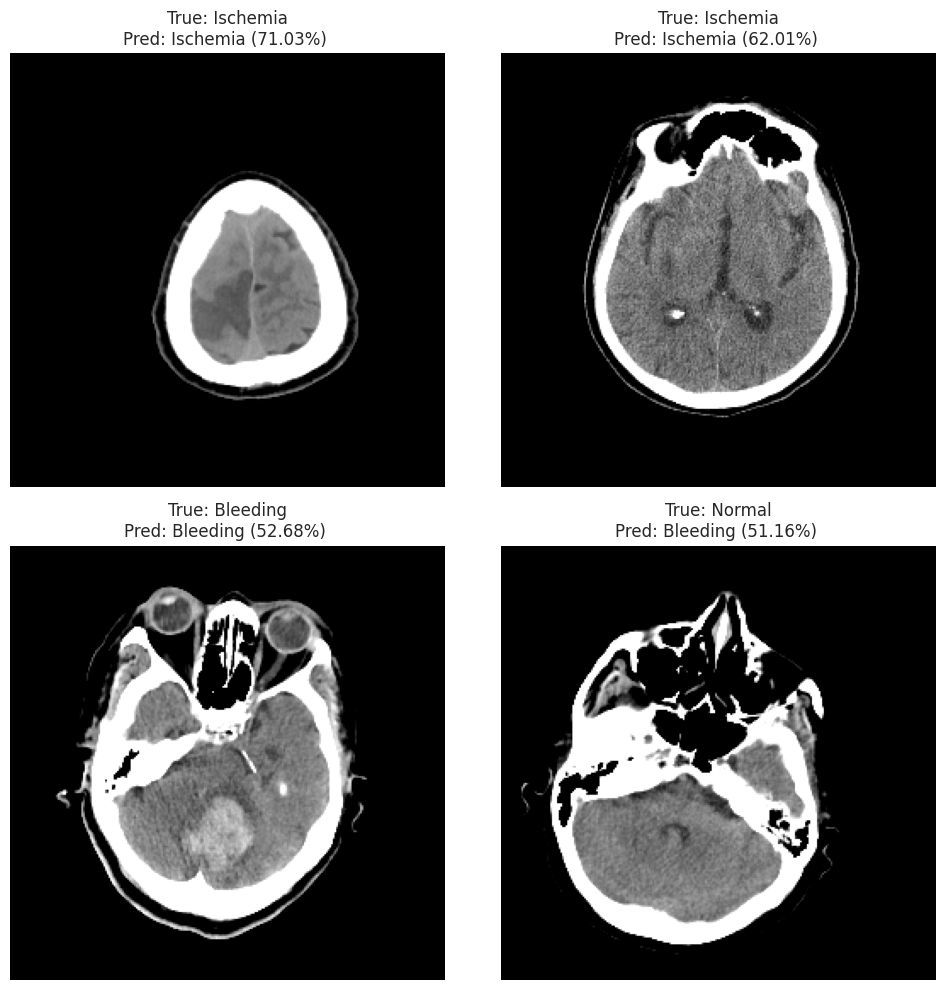

In [129]:
# Identify best model
best_model_row = df.loc[df['F1 Score'].idxmax()]
best_model_name = best_model_row['Model']
print(f"\nBest performing model based on F1 Score: {best_model_name}")

# Recreate the class_indices to map predicted numerical labels back to class names
class_labels = train_generator.class_indices
idx_to_class = {v: k for k, v in class_labels.items()}

# Collect all image paths from the test directory
all_test_image_paths = []
for cls in os.listdir(test_dir):
    class_path = os.path.join(test_dir, cls)
    for img_name in os.listdir(class_path):
        all_test_image_paths.append(os.path.join(class_path, img_name))

# Randomly select at least 4 images
num_images_to_predict = 4
if len(all_test_image_paths) < num_images_to_predict:
    num_images_to_predict = len(all_test_image_paths)
    print(f"Warning: Only {num_images_to_predict} images available in the test set.")

selected_image_paths = random.sample(all_test_image_paths, num_images_to_predict)

plt.figure(figsize=(10, 10))
for i, img_path in enumerate(selected_image_paths):
    # Load and preprocess image
    img = tf.keras.preprocessing.image.load_img(img_path, target_size=img_dims)
    img_array = tf.keras.preprocessing.image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)  # Add batch dimension
    img_array = img_array / 255.0  # Normalize

    # Get true label from path
    true_label_name = os.path.basename(os.path.dirname(img_path))

    # Make prediction
    predictions = mob_model.predict(img_array, verbose=0)
    predicted_class_index = np.argmax(predictions, axis=1)[0]
    predicted_class_name = idx_to_class[predicted_class_index]
    confidence = np.max(predictions) * 100

    # Plot image and prediction
    plt.subplot(2, 2, i + 1)
    plt.imshow(img)
    plt.title(f"True: {true_label_name}\nPred: {predicted_class_name} ({confidence:.2f}%) ")
    plt.axis('off')

plt.tight_layout()
plt.show()
